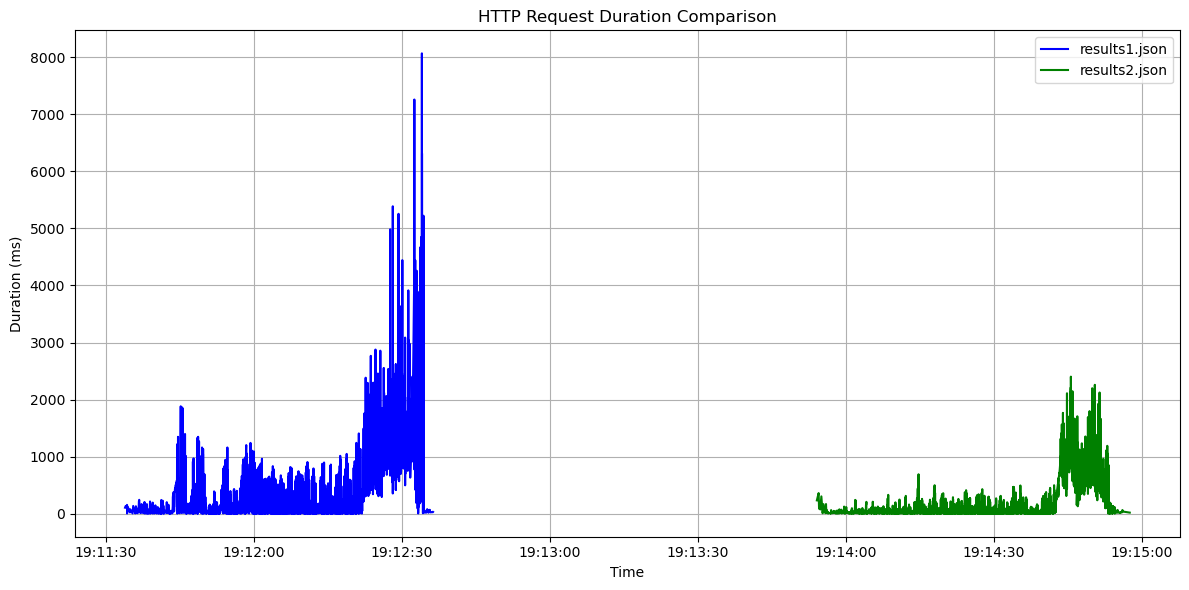

In [5]:
import json
import pandas as pd
import matplotlib.pyplot as plt

def load_k6_data(filename):
    with open(filename) as f:
        lines = [json.loads(line) for line in f if line.strip()]
    data = [line for line in lines if line.get('type') == 'Point' and line.get('metric') == 'http_req_duration']
    timestamps = [pd.to_datetime(item['data']['time']) for item in data]
    durations = [item['data']['value'] for item in data]
    return pd.DataFrame({'Time': timestamps, 'Duration': durations})

# Load both files
df1 = load_k6_data('results1.json')
df2 = load_k6_data('results2.json')

# Optional: Sort by time
df1.sort_values('Time', inplace=True)
df2.sort_values('Time', inplace=True)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df1['Time'], df1['Duration'], label='results1.json', color='blue')
plt.plot(df2['Time'], df2['Duration'], label='results2.json', color='green')

plt.title('HTTP Request Duration Comparison')
plt.xlabel('Time')
plt.ylabel('Duration (ms)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()